# Ventilation Index (Tang & Emanuel 2012) Demo

This notebook computes the [Tang & Emanuel (2012)](https://journals.ametsoc.org/view/journals/bams/93/12/bams-d-11-00165.1.xml) ventilation index (VI, $\Lambda$) step-by-step using:

- TE12 Eq. (1):  $\Lambda = (u_{\mathrm{shear}} / u_{PI})\,\chi_m$
- TE12 Eq. (2):  $\chi_m = (s_m^* - s_m) / (s_{SST}^* - s_b)$

The demo uses a single-column **ERA5 October 2024 monthly-mean** environment near **Hurricane Milton's (2024)** peak-intensity location, read from the tracked `data/era5_demo_subset.nc`, so the thermodynamic profile and 850–200 hPa shear come from the same dataset.

**On the monthly mean:** a monthly-mean field is a *climatological* diagnostic and is perfectly appropriate for climatological PI/VI analyses across many storms or seasons. It is *not* the pre-storm environment of this individual storm — to characterize the environment a specific storm developed in, you would use sub-monthly fields 3–5 days ahead of passage (so the storm does not contaminate its own environment). Milton's location is used here purely as a concrete example.

Notes
-----
- We approximate 2m boundary-layer conditions using the lowest model level from the profile (you would use true 2m fields in practice).
- The goal here is transparency: show how each TE12 term is computed and how each factor influences $\Lambda$.

In [1]:
import sys
from pathlib import Path

# This repo uses a src/ layout. Locate the repo root (by finding src/tcpyPI) and add
# src/ to the import path so this runs without installation, from anywhere.
here = Path.cwd().resolve()
repo_root = None
for cand in [here] + list(here.parents):
    if (cand / "src" / "tcpyPI").is_dir():
        repo_root = cand
        break
if repo_root is None:
    raise RuntimeError(
        "Could not locate repo root (expected src/tcpyPI). "
        "Run from within the repo or install with `pip install -e .`."
    )
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import matplotlib.pyplot as plt

import tcpyPI
import tcpyPI.utilities as util

print("Using tcpyPI from:", tcpyPI.__file__)

Using tcpyPI from: /home/dgilford/tcpyPI/src/tcpyPI/__init__.py


## 1) Load an ERA5 October 2024 profile (Milton reference)

- `P` in hPa
- `TC` in °C
- `R` in g/kg (mixing ratio, derived from specific humidity)


In [2]:
import xarray as xr

# Single-column ERA5 Oct-2024 monthly-mean environment near Hurricane Milton's (2024)
# peak-intensity location, from the tracked demo subset (built by
# data/build_sample_data_era5_oct2024.py). Runs on a fresh clone with no IBTrACS or
# full ERA5 download.
DEMO_PATH = repo_root / "data" / "era5_demo_subset.nc"

ds = xr.open_dataset(DEMO_PATH)
milton_lat = ds.attrs["milton_lat"]
milton_lon_360 = ds.attrs["milton_lon"]
print("Reference:", ds.attrs["milton_time"], "| lat/lon (deg E):", milton_lat, milton_lon_360)

# Single column: pl_point and sl_point are the same dataset.
pl_point = ds.sortby("pressure_level", ascending=False)
sl_point = ds

P = pl_point["pressure_level"].values.astype(float)
TC = pl_point["t"].values.astype(float) - 273.15  # K -> C
q = pl_point["q"].values.astype(float)            # specific humidity, kg/kg
R = (q / (1.0 - q)) * 1000.0                       # mixing ratio, g/kg

SSTC = float(sl_point["sst"].values - 273.15)     # K -> C
MSL = float(sl_point["msl"].values / 100.0)       # Pa -> hPa

print("Profile levels:", len(P))
print("SSTC:", float(SSTC), "C")
print("MSL:", float(MSL), "hPa")

Reference: 2024-10-07 20:00 UTC | lat/lon (deg E): 21.75 269.0
Profile levels: 29
SSTC: 28.928375244140625 C
MSL: 1013.6218872070312 hPa


## 2) Compute PI (`u_PI`) with tcpyPI

We use the default `outflow_source="cape_star"` and `CKCD=0.9`.

In [3]:
VMAX, PMIN, IFL, T0, OTL = tcpyPI.pi(SSTC, MSL, P, TC, R, CKCD=0.9)
print("IFL:", IFL)
print("u_PI (VMAX):", VMAX, "m/s")
print("T0:", T0, "K")
print("OTL:", OTL, "hPa")
print("PMIN:", PMIN, "hPa")

IFL: 1
u_PI (VMAX): 80.70671348974075 m/s
T0: 196.37557404053322 K
OTL: 91.0602883038324 hPa
PMIN: 911.7930271018403 hPa


## 3) Compute deep-layer shear from ERA5 (850–200 hPa)

Tang & Emanuel define `u_shear = |u850 - u200|` (bulk 850–200 hPa shear magnitude).
For this demo, we compute the bulk 850–200 hPa shear magnitude from ERA5 u/v at the Milton reference grid point.

850 hPa wind (u,v): (-4.0504608154296875, -1.4140357971191406) m/s
200 hPa wind (u,v): (7.90618896484375, 5.831311225891113) m/s
u_shear (850–200): 13.980576792534576 m/s


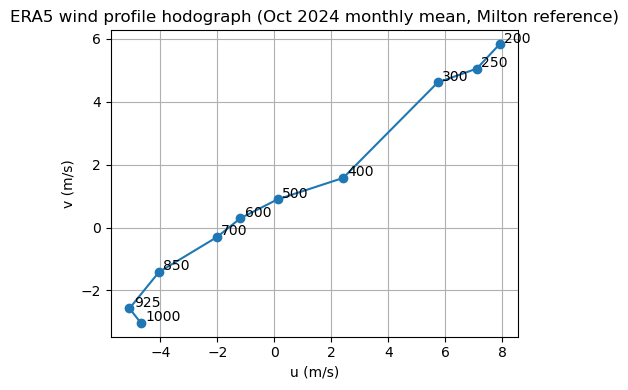

In [4]:
p_wind = np.array([1000, 925, 850, 700, 600, 500, 400, 300, 250, 200], dtype=float)

u = pl_point["u"].sel(pressure_level=p_wind, method="nearest").values.astype(float)
v = pl_point["v"].sel(pressure_level=p_wind, method="nearest").values.astype(float)

u850 = float(pl_point["u"].sel(pressure_level=850.0, method="nearest").values)
v850 = float(pl_point["v"].sel(pressure_level=850.0, method="nearest").values)
u200 = float(pl_point["u"].sel(pressure_level=200.0, method="nearest").values)
v200 = float(pl_point["v"].sel(pressure_level=200.0, method="nearest").values)
u_shear = float(np.hypot(u850 - u200, v850 - v200))
print("850 hPa wind (u,v):", (u850, v850), "m/s")
print("200 hPa wind (u,v):", (u200, v200), "m/s")
print("u_shear (850–200):", u_shear, "m/s")

plt.figure(figsize=(5, 4))
plt.plot(u, v, "o-")
for pi, ui, vi in zip(p_wind, u, v):
    plt.text(ui + 0.15, vi + 0.05, f"{int(pi)}")
plt.xlabel("u (m/s)")
plt.ylabel("v (m/s)")
plt.title("ERA5 wind profile hodograph (Oct 2024 monthly mean, Milton reference)")
plt.grid(True)
plt.tight_layout()
plt.show()

## 4) Compute the entropy deficit χm step-by-step

We use midlevel `p_mid = 600 hPa` as in TE12, and compute:

- `s_m`: environmental entropy at 600 hPa
- `s_m*`: saturation entropy at 600 hPa (using environmental temperature at 600 hPa)
- `s_SST*`: saturation entropy at SST at surface pressure
- `s_b`: boundary-layer entropy (here approximated using lowest-level profile as “2m”)


In [5]:
p_mid = 600.0
mid_i = int(np.argmin(np.abs(P - p_mid)))

T_mid_C = float(TC[mid_i])
T_mid_K = T_mid_C + 273.15
R_mid_gg = float(R[mid_i]) * 0.001  # g/kg -> g/g

# sm
s_m = util.entropy_S(T_mid_K, R_mid_gg, p_mid)

# s*m: saturation at midlevel
es_mid = util.es_cc(T_mid_C)
R_mid_sat = util.rv(es_mid, p_mid)
s_m_star = util.entropy_S(T_mid_K, R_mid_sat, p_mid)

# s*SST: saturation at SST and surface pressure
SST_K = SSTC + 273.15
es_sst = util.es_cc(SSTC)
R_sst_sat = util.rv(es_sst, float(MSL))
s_sst_star = util.entropy_S(SST_K, R_sst_sat, float(MSL))

# sb: boundary layer (2m proxy)
T2m_C = float(TC[0])
T2m_K = T2m_C + 273.15
R2m_gg = float(R[0]) * 0.001
s_b = util.entropy_S(T2m_K, R2m_gg, float(MSL))

chi_m = (s_m_star - s_m) / (s_sst_star - s_b)

print("sm      :", s_m)
print("sm_star :", s_m_star)
print("sSST_star:", s_sst_star)
print("sb      :", s_b)
print("chi_m   :", chi_m)

sm      : 3920.6734084687673
sm_star : 4000.8924013804635
sSST_star: 4341.537443410606
sb      : 4135.460436489114
chi_m   : 0.38926707113063164


### (Optional) Compare against the helper in tcpyPI

This uses the same defaults described in the function docstring.

We also compare two entropy-method choices for TE12 Eq. (2):
- `emanuel94`: uses `tcpyPI.utilities.entropy_S` (what tcpyPI uses elsewhere)
- `bryan2008`: the pseudo-adiabatic entropy described in TE12 Eq. (3)

These methods can yield different χm and thus different Λ.

In [6]:
chi_m_api_emanuel = tcpyPI.entropy_deficit_te12_from_profile(
    P,
    TC,
    R,
    T_units="C",
    q_units="g/kg",
    SST=SSTC,
    SST_units="C",
    psfc_hpa=MSL,
    T2m=T2m_C,
    q2m=float(R[0]),
    entropy_method="emanuel94",
)
chi_m_api_bryan = tcpyPI.entropy_deficit_te12_from_profile(
    P,
    TC,
    R,
    T_units="C",
    q_units="g/kg",
    SST=SSTC,
    SST_units="C",
    psfc_hpa=MSL,
    T2m=T2m_C,
    q2m=float(R[0]),
    entropy_method="bryan2008",
)

print("chi_m (manual, Emanuel-style):", chi_m)
print("chi_m (API, emmanuel94)      :", chi_m_api_emanuel)
print("chi_m (API, bryan2008)       :", chi_m_api_bryan)
print("Δ(bryan - emanuel)           :", float(chi_m_api_bryan - chi_m_api_emanuel))

chi_m (manual, Emanuel-style): 0.38926707113063164
chi_m (API, emmanuel94)      : 0.38926707113063164
chi_m (API, bryan2008)       : 0.3884449305193642
Δ(bryan - emanuel)           : -0.0008221406112674523


In [7]:
# Compare s_m* definitions (storm-core saturation entropy at midlevels)
# - env_T_at_pmid: s* at p_mid using environmental T(p_mid) with RH=100%
# - moist_adiabat_from_sst: lift a saturated parcel from SST at psfc to p_mid (moist adiabat)

chi_envT_emanuel = tcpyPI.entropy_deficit_te12_from_profile(
    P,
    TC,
    R,
    T_units="C",
    q_units="g/kg",
    SST=SSTC,
    SST_units="C",
    psfc_hpa=MSL,
    T2m=T2m_C,
    q2m=float(R[0]),
    entropy_method="emanuel94",
    s_m_star_source="env_T_at_pmid",
)
chi_moist_emanuel = tcpyPI.entropy_deficit_te12_from_profile(
    P,
    TC,
    R,
    T_units="C",
    q_units="g/kg",
    SST=SSTC,
    SST_units="C",
    psfc_hpa=MSL,
    T2m=T2m_C,
    q2m=float(R[0]),
    entropy_method="emanuel94",
    s_m_star_source="moist_adiabat_from_sst",
)

chi_envT_bryan = tcpyPI.entropy_deficit_te12_from_profile(
    P,
    TC,
    R,
    T_units="C",
    q_units="g/kg",
    SST=SSTC,
    SST_units="C",
    psfc_hpa=MSL,
    T2m=T2m_C,
    q2m=float(R[0]),
    entropy_method="bryan2008",
    s_m_star_source="env_T_at_pmid",
)
chi_moist_bryan = tcpyPI.entropy_deficit_te12_from_profile(
    P,
    TC,
    R,
    T_units="C",
    q_units="g/kg",
    SST=SSTC,
    SST_units="C",
    psfc_hpa=MSL,
    T2m=T2m_C,
    q2m=float(R[0]),
    entropy_method="bryan2008",
    s_m_star_source="moist_adiabat_from_sst",
)

print('chi_m (emanuel94, env_T_at_pmid)        :', float(chi_envT_emanuel))
print('chi_m (emanuel94, moist_adiabat_from_sst):', float(chi_moist_emanuel))
print('chi_m (bryan2008, env_T_at_pmid)        :', float(chi_envT_bryan))
print('chi_m (bryan2008, moist_adiabat_from_sst):', float(chi_moist_bryan))

VI_envT_emanuel = tcpyPI.ventilation_index(u_shear, VMAX, chi_envT_emanuel)
VI_moist_emanuel = tcpyPI.ventilation_index(u_shear, VMAX, chi_moist_emanuel)
VI_envT_bryan = tcpyPI.ventilation_index(u_shear, VMAX, chi_envT_bryan)
VI_moist_bryan = tcpyPI.ventilation_index(u_shear, VMAX, chi_moist_bryan)

print('VI (emanuel94, env_T_at_pmid)        :', float(VI_envT_emanuel))
print('VI (emanuel94, moist_adiabat_from_sst):', float(VI_moist_emanuel))
print('VI (bryan2008, env_T_at_pmid)        :', float(VI_envT_bryan))
print('VI (bryan2008, moist_adiabat_from_sst):', float(VI_moist_bryan))


chi_m (emanuel94, env_T_at_pmid)        : 0.38926707113063164
chi_m (emanuel94, moist_adiabat_from_sst): 2.042265858002686
chi_m (bryan2008, env_T_at_pmid)        : 0.3884449305193642
chi_m (bryan2008, moist_adiabat_from_sst): 1.4846263838428122
VI (emanuel94, env_T_at_pmid)        : 0.0674315425003474
VI (emanuel94, moist_adiabat_from_sst): 0.35377545961164103
VI (bryan2008, env_T_at_pmid)        : 0.06728912560027692
VI (bryan2008, moist_adiabat_from_sst): 0.25717728141879787


### Why can this change be large?

For the TE12 entropy deficit,

$$\chi_m = \frac{s_m^* - s_m}{s_{SST}^* - s_b}$$

Switching `s_m_star_source` changes only the numerator term $s_m^*$:
- `env_T_at_pmid` uses $T(p_{mid})$ and sets RH=100%.
- `moist_adiabat_from_sst` lifts a *saturated* parcel from SST to $p_{mid}$. In our implementation this is treated as **constant saturation entropy**, so $s_m^*$ becomes approximately $s_{SST}^*$.

If the boundary layer is fairly humid, $(s_{SST}^* - s_b)$ can be modest, so changing $s_m^*$ can shift $\chi_m$ noticeably.

In [8]:
# Inspect the TE12 entropy terms (Emanuel-style entropy) to sanity-check magnitudes.
# This helps confirm the change is coming from physics/definitions, not a unit mistake.

import numpy as np
import tcpyPI.utilities as util

p_mid = 600.0
mid_i = int(np.argmin(np.abs(P - p_mid)))

SST_K = SSTC + 273.15
T2m_K = T2m_C + 273.15
T_mid_K = float(TC[mid_i]) + 273.15
R2m = float(R[0]) * 0.001       # g/kg -> g/g
R_mid = float(R[mid_i]) * 0.001 # g/kg -> g/g

# s_SST*: saturation entropy at SST (surface pressure)
es_sst = util.es_cc(SSTC)
R_sst_sat = util.rv(es_sst, float(MSL))
s_sst_star = util.entropy_S(SST_K, R_sst_sat, float(MSL))

# s_b: boundary-layer entropy at 2m
s_b = util.entropy_S(T2m_K, R2m, float(MSL))

# s_m: environmental entropy at p_mid
s_m = util.entropy_S(T_mid_K, R_mid, p_mid)

# s_m* (env_T_at_pmid): saturation entropy at p_mid using environmental T(p_mid)
es_mid = util.es_cc(float(TC[mid_i]))
R_mid_sat = util.rv(es_mid, p_mid)
s_m_star_envT = util.entropy_S(T_mid_K, R_mid_sat, p_mid)

# s_m* (moist_adiabat_from_sst): in this implementation, this is ~ s_SST*
# (computed by lifting along constant saturation entropy)
chi_envT = (s_m_star_envT - s_m) / (s_sst_star - s_b)
chi_moist = (s_sst_star - s_m) / (s_sst_star - s_b)

print('s_SST*   :', float(s_sst_star))
print('s_b      :', float(s_b))
print('s_m      :', float(s_m))
print('s_m* envT:', float(s_m_star_envT))
print('denom (s_SST* - s_b):', float(s_sst_star - s_b))
print('chi_m (env_T_at_pmid)        :', float(chi_envT))
print('chi_m (moist_adiabat_from_sst):', float(chi_moist))


s_SST*   : 4341.537443410606
s_b      : 4135.460436489114
s_m      : 3920.6734084687673
s_m* envT: 4000.8924013804635
denom (s_SST* - s_b): 206.07700692149228
chi_m (env_T_at_pmid)        : 0.38926707113063164
chi_m (moist_adiabat_from_sst): 2.0422658559970857


## 5) Compute the ventilation index Λ

TE12 Eq. (1):  $\Lambda = (u_{\mathrm{shear}} / u_{PI})\,\chi_m$

In [9]:
VI = tcpyPI.ventilation_index(u_shear, VMAX, chi_m, formulation="te12")
print("VI (Lambda):", VI)

VI (Lambda): 0.0674315425003474


## 6) Visualize the drivers of $\Lambda$

Because TE12 Eq. (1) is multiplicative, it is often clearer to look in log space:

$$\ln\Lambda = \ln u_{\mathrm{shear}} - \ln u_{PI} + \ln \chi_m$$

This makes the *relative* influence of each factor easy to interpret (elasticities):
- a 1% increase in $u_{\mathrm{shear}}$ increases $\Lambda$ by ~1%
- a 1% increase in $u_{PI}$ decreases $\Lambda$ by ~1%
- a 1% increase in $\chi_m$ increases $\Lambda$ by ~1%

We plot both the log-space contributions and a simple one-at-a-time perturbation test (±20%) to show sensitivities.


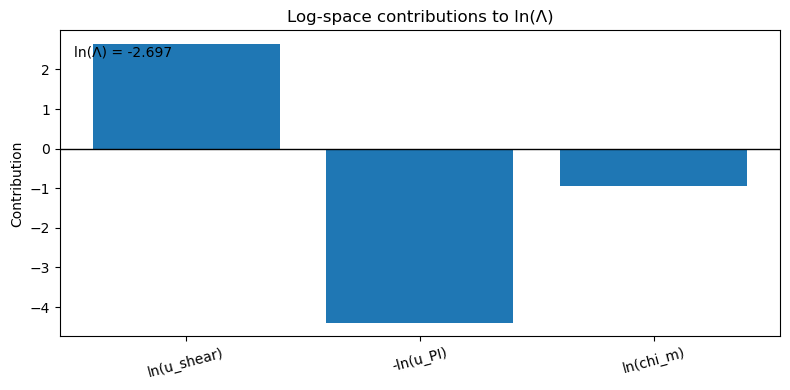

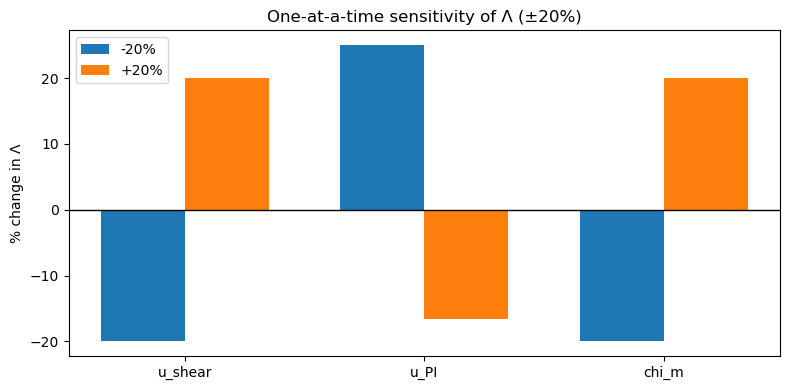

In [10]:
# Log-space decomposition (additive contributions)
ln_shear = float(np.log(u_shear))
ln_chi = float(np.log(chi_m))
ln_pi = float(np.log(VMAX))
ln_lambda = float(np.log(VI))

terms = {
    'ln(u_shear)': ln_shear,
    '-ln(u_PI)': -ln_pi,
    'ln(chi_m)': ln_chi,
}

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color='k', linewidth=1)
ax.bar(list(terms.keys()), list(terms.values()))
ax.set_title('Log-space contributions to ln(Λ)')
ax.set_ylabel('Contribution')
ax.text(0.02, 0.95, f'ln(Λ) = {ln_lambda:.3f}', transform=ax.transAxes, va='top')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# One-at-a-time sensitivity: perturb each factor by ±20%
def lambda_from(u_shear_val, u_pi_val, chi_val):
    return (u_shear_val / u_pi_val) * chi_val

base = float(VI)
perturb = 0.20
scenarios = []
for name, (u_shear_val, u_pi_val, chi_val) in [
    ('u_shear', (u_shear, VMAX, chi_m)),
    ('u_PI', (u_shear, VMAX, chi_m)),
    ('chi_m', (u_shear, VMAX, chi_m)),
]:
    if name == 'u_shear':
        low = lambda_from(u_shear * (1 - perturb), VMAX, chi_m)
        high = lambda_from(u_shear * (1 + perturb), VMAX, chi_m)
    elif name == 'u_PI':
        low = lambda_from(u_shear, VMAX * (1 - perturb), chi_m)
        high = lambda_from(u_shear, VMAX * (1 + perturb), chi_m)
    else:  # chi_m
        low = lambda_from(u_shear, VMAX, chi_m * (1 - perturb))
        high = lambda_from(u_shear, VMAX, chi_m * (1 + perturb))
    scenarios.append((name, (low / base - 1) * 100, (high / base - 1) * 100))

labels = [s[0] for s in scenarios]
low_changes = [s[1] for s in scenarios]
high_changes = [s[2] for s in scenarios]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color='k', linewidth=1)
ax.bar(x - width/2, low_changes, width, label='-20%')
ax.bar(x + width/2, high_changes, width, label='+20%')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('% change in Λ')
ax.set_title('One-at-a-time sensitivity of Λ (±20%)')
ax.legend()
plt.tight_layout()
plt.show()
